# Extra EDA — numbers and figures for Section 2 of the report

Computes the missing dataset statistics and the single combined figure we'll use:

1. **Train/val/test paper counts** by year (rubric: data splits)
2. **Supervision example counts** per split (train total, val, test)
3. **Number of FoS fields at L0 / L1 / L2** (brief hierarchy overview)
4. **Combined 3-panel figure** for the report:
   - Panel A: training examples per year
   - Panel B: graph size (papers) per year
   - Panel C: pairwise cosine similarity histogram of paper title embeddings

## Imports and configuration

In [2]:
import re
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt

from H2GB.datasets import OAGDataset

OAG_ROOT = Path("./data/OAG")
PROCESSED_DIR = Path("./data/processed_v2")
FIG_DIR = Path("./figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

VAL_YEAR = 2017
TEST_YEAR = 2018
COSINE_SAMPLE_SIZE = 10000

plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3,
                     'savefig.bbox': 'tight', 'savefig.dpi': 150})

## Step 1 — Load OAG-CS

Same as the main EDA notebook. Slow ($\sim$1 min) but only runs once.

In [3]:
OAGDataset.names['oag-cs'] = 'cs'
OAGDataset.urls['oag-cs'] = 'bypassed'

class CS_OAGDataset(OAGDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        self.name = 'oag-cs'
        super(OAGDataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)
    def download(self):
        pass

t0 = time.time()
dataset = CS_OAGDataset(root=str(OAG_ROOT))
data = dataset[0]
X = data['paper'].x
years = data['paper'].year
num_papers = X.shape[0]
print(f"Loaded in {time.time()-t0:.1f}s — {num_papers:,} papers")

Loaded in 1.3s — 546,704 papers


## Step 2 — Train / val / test paper counts (by year)

Direct counts from the `years` tensor.

In [4]:
train_papers = (years < VAL_YEAR).sum().item()
val_papers   = (years == VAL_YEAR).sum().item()
test_papers  = (years >= TEST_YEAR).sum().item()
total = train_papers + val_papers + test_papers

print("Paper-level temporal splits (used as supervision-year buckets):")
print(f"  Train (year < {VAL_YEAR}):    {train_papers:>10,} papers ({100*train_papers/num_papers:.1f}%)")
print(f"  Val   (year = {VAL_YEAR}):    {val_papers:>10,} papers ({100*val_papers/num_papers:.1f}%)")
print(f"  Test  (year >= {TEST_YEAR}):  {test_papers:>10,} papers ({100*test_papers/num_papers:.1f}%)")
print(f"  Total accounted:              {total:>10,} papers")

Paper-level temporal splits (used as supervision-year buckets):
  Train (year < 2017):       456,776 papers (83.6%)
  Val   (year = 2017):        39,072 papers (7.1%)
  Test  (year >= 2018):      50,856 papers (9.3%)
  Total accounted:                 546,704 papers


## Step 3 — Supervision example counts per split

Loads the supervision lists from each `train_year_*.pt`, `val.pt`, `test.pt` and sums.

In [5]:
if (PROCESSED_DIR / 'train_years.pt').exists():
    train_years_list = torch.load(PROCESSED_DIR / 'train_years.pt', weights_only=False)
    per_year_counts = []
    per_year_graph_sizes = []
    for y in train_years_list:
        td = torch.load(PROCESSED_DIR / f'train_year_{y}.pt', weights_only=False)
        per_year_counts.append((y, len(td['supervision'])))
        per_year_graph_sizes.append((y, td['homo_graph'].num_nodes))
        del td
    train_total = sum(c for _, c in per_year_counts)

    val_data = torch.load(PROCESSED_DIR / 'val.pt', weights_only=False)
    test_data = torch.load(PROCESSED_DIR / 'test.pt', weights_only=False)
    val_examples = len(val_data['supervision'])
    test_examples = len(test_data['supervision'])

    print("Supervision example counts (per-author, post-filtering):")
    print(f"  Training years: {train_years_list}")
    print(f"  Per-year breakdown:")
    for y, n in per_year_counts:
        gs = dict(per_year_graph_sizes)[y]
        print(f"    {y}: {n:>6,} examples  |  graph size: {gs:>7,} papers")
    print(f"  Train (total): {train_total:>10,}")
    print(f"  Val:           {val_examples:>10,}")
    print(f"  Test:          {test_examples:>10,}")
    print(f"  Mean train examples per year: {train_total/len(train_years_list):,.0f}")
else:
    print(f"Skipped — {PROCESSED_DIR} not found. Run v2_02b_prepare_oag_cs.ipynb first.")

Supervision example counts (per-author, post-filtering):
  Training years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
  Per-year breakdown:
    2005: 14,780 examples  |  graph size: 107,163 papers
    2006: 16,944 examples  |  graph size: 125,063 papers
    2007: 19,955 examples  |  graph size: 144,229 papers
    2008: 22,485 examples  |  graph size: 165,790 papers
    2009: 26,268 examples  |  graph size: 189,419 papers
    2010: 29,597 examples  |  graph size: 215,312 papers
    2011: 32,787 examples  |  graph size: 243,744 papers
    2012: 36,438 examples  |  graph size: 274,267 papers
    2013: 39,737 examples  |  graph size: 307,407 papers
    2014: 42,423 examples  |  graph size: 342,789 papers
    2015: 45,249 examples  |  graph size: 379,003 papers
    2016: 45,364 examples  |  graph size: 418,317 papers
  Train (total):    372,027
  Val:               43,562
  Test:              37,046
  Mean train examples per year: 31,002


## Step 4 — FoS field counts at L0 / L1 / L2

Quick scan over `PF_in_L*` edge types to count distinct fields per level.

In [6]:
fos_counts = {}
for et in data.edge_types:
    src, rel, dst = et
    if src == 'paper' and dst == 'field' and 'PF_in_L' in rel:
        m = re.search(r'L(\d+)', rel)
        if m:
            lvl = int(m.group(1))
            ei = data[et].edge_index
            n_fields = len(torch.unique(ei[1]))
            n_papers_tagged = len(torch.unique(ei[0]))
            fos_counts[lvl] = (n_fields, n_papers_tagged)

print("Field-of-study (FoS) hierarchy summary:")
print(f"  {'Level':<8}{'#Fields':>10}{'Papers tagged':>16}{'Coverage':>12}")
for lvl in sorted(fos_counts.keys()):
    n, pt = fos_counts[lvl]
    print(f"  L{lvl:<7}{n:>10,}{pt:>16,}{100*pt/num_papers:>11.1f}%")

print(f"\nFor the report: '6 FoS levels (L0 broad to L5 fine), with L2 (17,750 fields, 96.9% coverage) used for hard-negative sampling.'")

Field-of-study (FoS) hierarchy summary:
  Level      #Fields   Papers tagged    Coverage
  L0              13         546,704      100.0%
  L1             275         546,704      100.0%
  L2          17,750         529,808       96.9%
  L3          14,615         429,647       78.6%
  L4           7,245         203,388       37.2%
  L5           5,877         114,940       21.0%

For the report: '6 FoS levels (L0 broad to L5 fine), with L2 (17,750 fields, 96.9% coverage) used for hard-negative sampling.'


## Step 5 — Combined 3-panel figure for the report

Three side-by-side panels:
- Panel A: training examples per supervision year (size of available training data)
- Panel B: graph size (papers `< y`) per supervision year (model's input size grows over time)
- Panel C: pairwise cosine similarity histogram of paper title embeddings (motivates GNN choice — features alone are highly clustered)

Saved as `figures/eda_section2.png` (single file, ready for `\includegraphics`).

In [7]:
# Pairwise cosine sample (re-compute to ensure same data shown)
rng = np.random.default_rng(0)
samp_idx = rng.choice(num_papers, size=COSINE_SAMPLE_SIZE, replace=False)
Xs = X[samp_idx]
Xs_norm = Xs / Xs.norm(dim=-1, keepdim=True).clamp(min=1e-8)
sim = Xs_norm @ Xs_norm.t()
iu = torch.triu_indices(sim.shape[0], sim.shape[0], offset=1)
cos_vals = sim[iu[0], iu[1]].numpy()
print(f"Pairwise cosine sample: {len(cos_vals):,} pairs, mean={cos_vals.mean():.4f}, median={np.median(cos_vals):.4f}")

Pairwise cosine sample: 49,995,000 pairs, mean=0.9909, median=0.9913


Build the figure. Compact 1$\times$3 layout sized for a single column in NeurIPS format.

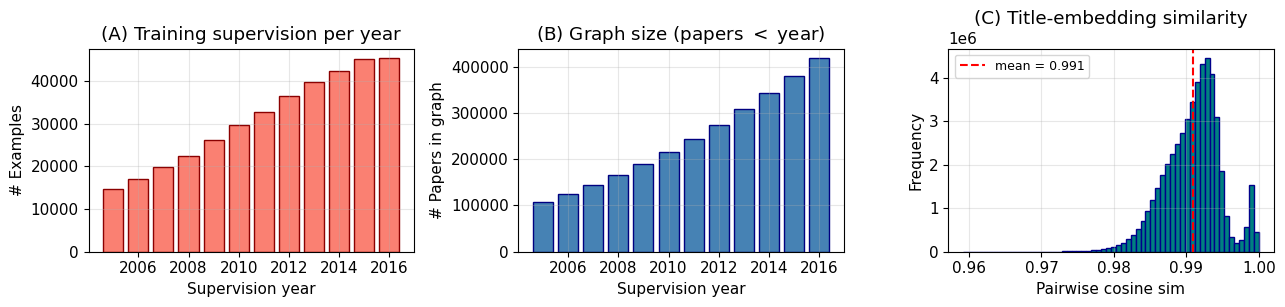

Saved: figures/eda_section2.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

# Panel A: Training examples per year
if 'per_year_counts' in dir() and per_year_counts:
    yrs_a = [y for y, _ in per_year_counts]
    cnt_a = [c for _, c in per_year_counts]
    axes[0].bar(yrs_a, cnt_a, color='salmon', edgecolor='darkred')
    axes[0].set_xlabel('Supervision year')
    axes[0].set_ylabel('# Examples')
    axes[0].set_title('(A) Training supervision per year')

# Panel B: Graph size per year
if 'per_year_graph_sizes' in dir() and per_year_graph_sizes:
    yrs_b = [y for y, _ in per_year_graph_sizes]
    sz_b = [s for _, s in per_year_graph_sizes]
    axes[1].bar(yrs_b, sz_b, color='steelblue', edgecolor='navy')
    axes[1].set_xlabel('Supervision year')
    axes[1].set_ylabel('# Papers in graph')
    axes[1].set_title(r'(B) Graph size (papers $<$ year)')

# Panel C: Pairwise cosine similarity histogram
axes[2].hist(cos_vals, bins=60, color='teal', edgecolor='darkblue')
axes[2].axvline(cos_vals.mean(), color='red', linestyle='--',
                label=f'mean = {cos_vals.mean():.3f}')
axes[2].set_xlabel('Pairwise cosine sim')
axes[2].set_ylabel('Frequency')
axes[2].set_title('(C) Title-embedding similarity')
axes[2].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_section2.png')
plt.show()
print(f"Saved: {FIG_DIR / 'eda_section2.png'}")

## Step 6 — Final number checklist for Section 2

Print everything in one block so it's easy to copy into the LaTeX.

In [9]:
print("=" * 60)
print("NUMBERS FOR REPORT SECTION 2")
print("=" * 60)
print()
print("--- Graph size ---")
print(f"  Papers:                    {num_papers:,}")
print(f"  Authors:                   {data['author'].num_nodes:,}")
print(f"  Citation edges:            {data['paper', 'PP_cite', 'paper'].edge_index.shape[1]:,}")
print(f"  Year range:                {years.min().item()} – {years.max().item()}")
print(f"  Paper feature dim:         {X.shape[1]}")
print()
print("--- FoS hierarchy ---")
for lvl in sorted(fos_counts.keys()):
    n, pt = fos_counts[lvl]
    print(f"  L{lvl}: {n:>7,} fields  ({100*pt/num_papers:>5.1f}% coverage)")
print()
print("--- Splits (papers as supervision-year sources) ---")
print(f"  Train (year < {VAL_YEAR}):    {train_papers:>10,} papers")
print(f"  Val   (year = {VAL_YEAR}):    {val_papers:>10,} papers")
print(f"  Test  (year >= {TEST_YEAR}):  {test_papers:>10,} papers")
print()
if 'train_total' in dir():
    print("--- Splits (per-author supervision examples) ---")
    print(f"  Train (total):  {train_total:>10,} examples")
    print(f"  Val:            {val_examples:>10,} examples")
    print(f"  Test:           {test_examples:>10,} examples")
    print(f"  Train years:    {len(train_years_list)} (mean {train_total/len(train_years_list):,.0f} per year)")
print()
print("--- Cosine similarity (sample) ---")
print(f"  Pairs evaluated: {len(cos_vals):,}")
print(f"  Mean:            {cos_vals.mean():.4f}")
print(f"  Median:          {np.median(cos_vals):.4f}")
print(f"  10th percentile: {np.percentile(cos_vals, 10):.4f}")
print(f"  90th percentile: {np.percentile(cos_vals, 90):.4f}")
print()
print(f"--- Figure saved: {FIG_DIR / 'eda_section2.png'} ---")

NUMBERS FOR REPORT SECTION 2

--- Graph size ---
  Papers:                    546,704
  Authors:                   511,122
  Citation edges:            5,872,552
  Year range:                1922 – 2020
  Paper feature dim:         768

--- FoS hierarchy ---
  L0:      13 fields  (100.0% coverage)
  L1:     275 fields  (100.0% coverage)
  L2:  17,750 fields  ( 96.9% coverage)
  L3:  14,615 fields  ( 78.6% coverage)
  L4:   7,245 fields  ( 37.2% coverage)
  L5:   5,877 fields  ( 21.0% coverage)

--- Splits (papers as supervision-year sources) ---
  Train (year < 2017):       456,776 papers
  Val   (year = 2017):        39,072 papers
  Test  (year >= 2018):      50,856 papers

--- Splits (per-author supervision examples) ---
  Train (total):     372,027 examples
  Val:                43,562 examples
  Test:               37,046 examples
  Train years:    12 (mean 31,002 per year)

--- Cosine similarity (sample) ---
  Pairs evaluated: 49,995,000
  Mean:            0.9909
  Median:        